# Import Utility Class and Model Class

In [11]:

import io
from utility import *
from datetime import datetime
import torch
import numpy as np
from model import *




#Creation of the model

In [12]:
import torch.optim as optim
import matplotlib.pyplot as plt

device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )

print(f"Using {device} device")
answer = input("Do you want to load a model?(Yes/No)\n")

model = TradingModel(7,3,1000,0.2).to(device)
if answer == "Yes":
  nom = input("name of the file\n")
  model.load_state_dict(torch.load("model/"+nom))


loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

test_loss =0.0
val_loss = 0.0



Using cuda device


#Loading the data

In [13]:
import pandas as pd

df = pd.read_csv("analysed_dataframe/NVDA_2010-2023.csv")


#Preparing Data

In [14]:
def prepare_data(dataframe):
    datas = []
    targets = []
    for i in range(len(dataframe) - 1):
        current_row = dataframe.iloc[i]
        next_row = dataframe.iloc[i + 1]
        input_data = torch.tensor([current_row["deltaClosePrice"],current_row["deltaHighPrice"],current_row["deltaLowPrice"],current_row["deltaSMA"],current_row["deltaEMA"], current_row["rsi"],current_row["volume"]])
        target = torch.tensor([next_row["deltaClosePrice"],next_row["deltaHighPrice"], next_row["deltaLowPrice"]])
        datas.append(input_data)
        targets.append(target)
    print(len(datas))
    return datas, targets

data, target = prepare_data(df)

47330


#Normalisation of Data

In [15]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = torch.stack(data)
target = torch.stack(target)

standard_data = data[:,:5] 
to_normalize_volume = data[:,6].reshape(-1, 1) 
rsi = data[:,5].reshape(-1,1)


scaler_volume = MinMaxScaler()
scaler_rsi = MinMaxScaler()

normalized_volume = torch.tensor(scaler_volume.fit_transform(to_normalize_volume))
normalized_rsi = torch.tensor(scaler_rsi.fit_transform(rsi))


normalized_input = torch.cat((standard_data,normalized_rsi, normalized_volume),1)




# Creation of the dataset

In [16]:
from torch.utils.data import Dataset, Subset

class LSTM_Dataset(Dataset):
  def __init__(self,inputs,labels,time_series_len):
    self.inputs = inputs
    self.labels = labels
    self.time_series_len = time_series_len
    shifted_input, shifted_target = self.shift_data()
    self.inputs = torch.stack(shifted_input)
    self.labels = torch.stack(shifted_target)
    print(self.inputs.shape)
    print(self.labels.shape)

  def shift_data(self):
    shifted_target = []
    shifted_input = []
    inputs = self.inputs
    labels = self.labels
    for start in range(0, len(inputs) - self.time_series_len, 1):
        shifted_input.append(inputs[start:start+self.time_series_len])
        shifted_target.append(labels[start+self.time_series_len])
    return shifted_input,shifted_target

  def __getitem__(self,idx):
      return self.inputs[idx], self.labels[idx]

  def __len__(self):
      return len(self.inputs)

dataset = LSTM_Dataset(inputs=normalized_input, labels=target,time_series_len=8)

training_index = int(len(dataset)*0.7)
validating_index = int(len(dataset)*0.15)


def generate_indices(start,end):
  indices = []
  for i in range(start, end):
    indices.append(i)
  return indices

training_indices = generate_indices(0,training_index)
validating_indices = generate_indices(training_index,training_index+validating_index)
testing_indices = generate_indices(training_index+validating_index,len(dataset))
training_set = Subset(dataset,training_indices)
validation_set = Subset(dataset,validating_indices)
testing_set = Subset(dataset,testing_indices)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=64, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False)
testing_loader = torch.utils.data.DataLoader(testing_set, batch_size=1, shuffle=False)

torch.Size([47322, 8, 7])
torch.Size([47322, 3])


In [17]:
def train_one_epoch(set_loader,train=False):
  running_loss = 0.0
  predicted = []
  target = []
  for i, data in enumerate(set_loader):
        optimizer.zero_grad()

        inputs, labels = data


        inputs = inputs.to(torch.float32)
        labels = labels.to(torch.float32)

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        output = model(inputs)

        loss = loss_fn(output, labels)
        running_loss +=loss.item()
        if train :
          loss.backward()
          optimizer.step()
          scheduler.step(running_loss)
        else:
          predicted.append(output[-1].cpu().detach())
          target.append(labels[-1].cpu().detach())
  print(running_loss)
  if train:
    return running_loss
  else:
    return predicted, target

#Training

In [18]:
num_epochs = 100
model.train(True)
for epoch in range(num_epochs):
      loss = train_one_epoch(training_loader, True)
      print(f"Epoch {epoch} loss: {loss}")

2.31264152112999
Epoch 0 loss: 2.31264152112999
0.0774235482676886
Epoch 1 loss: 0.0774235482676886
0.07251130594522692
Epoch 2 loss: 0.07251130594522692
0.06730793635506416
Epoch 3 loss: 0.06730793635506416
0.0645006806080346
Epoch 4 loss: 0.0645006806080346
0.062538956735807
Epoch 5 loss: 0.062538956735807
0.0616975422926771
Epoch 6 loss: 0.0616975422926771
0.06180045435758075
Epoch 7 loss: 0.06180045435758075
0.062321796227479354
Epoch 8 loss: 0.062321796227479354
0.061900468110252405
Epoch 9 loss: 0.061900468110252405
0.06140786994728842
Epoch 10 loss: 0.06140786994728842
0.06152626185212284
Epoch 11 loss: 0.06152626185212284
0.06191509624113678
Epoch 12 loss: 0.06191509624113678
0.06159915237731184
Epoch 13 loss: 0.06159915237731184
0.06184383656727732
Epoch 14 loss: 0.06184383656727732
0.06103319390967954
Epoch 15 loss: 0.06103319390967954
0.061286161093448754
Epoch 16 loss: 0.061286161093448754
0.06150488873390714
Epoch 17 loss: 0.06150488873390714
0.06104370350658428
Epoch 18 l

# Validation

0.02203427395943436


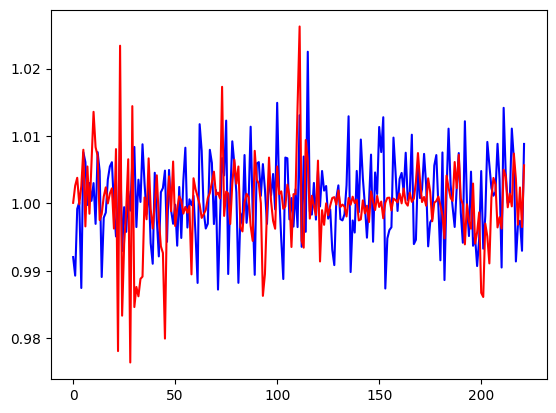

In [19]:
predicted, target = train_one_epoch(validation_loader)

time = np.arange(0, len(predicted))
model.train(False)
model.eval()
predicted = torch.stack(predicted)
target = torch.stack(target)



#plt.plot(time,predicted[:,0],'-', color='green')
#plt.plot(time,target[:,0],'-', color='yellow')

plt.plot(time,predicted[:,0],'-', color='blue')
plt.plot(time,target[:,0],'-', color='red')
plt.show()

#Testing

16.042677487307994


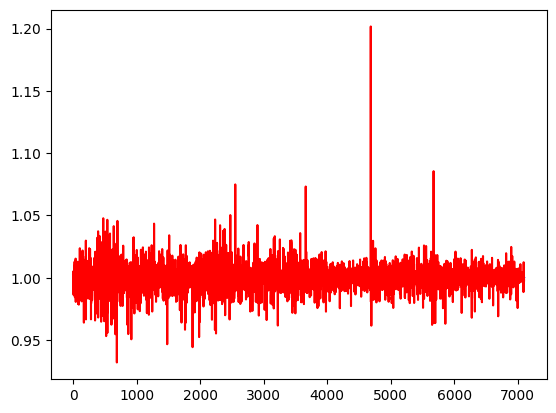

In [20]:
model.train(False)
predicted, target = train_one_epoch(testing_loader, False)

time = np.arange(0, len(predicted))



predicted = torch.stack(predicted)
target = torch.stack(target)



#plt.plot(time,predicted[:,0],'-', color='green')
#plt.plot(time,target[:,0],'-', color='yellow')

plt.plot(time,predicted[:,0],'-', color='blue')
plt.plot(time,target[:,0],'-', color='red')
plt.show()

In [21]:
torch.save(model.state_dict(), 'model/version1k8s.pth')
